# **Transformers**
----

En este Notebook aprenderemos a trabajar con modelos basados en _Transformers_ utilizando [keras](https://keras.io/keras_hub/api/modeling_layers/). Los Transformers son una arquitectura de red neuronal que revolucionó el campo del procesamiento del lenguaje natural y que ahora se utiliza en muchas otras áreas del aprendizaje profundo. Fueron introducidos en el artículo ["Attention Is All You Need"](https://arxiv.org/abs/1706.03762) en 2017 y desde entonces han demostrado ser muy eficaces para tareas como la traducción automática, el resumen de texto y la generación de texto, calsificación de imagenes, entre otras.

<center><img src="https://cdn.educba.com/academy/wp-content/uploads/2022/09/Keras-Transformer.jpg" alt ="Tranformer en keras"width="60%"></center>

En este notebook veremos:

* Cómo funciona un _Transformer_.
* Cómo construir un _Transformer_ en _Keras_ para clasificación de textos.
* Cómo construir un _Transformer_ en _Keras_ para clasificación de imágenes.



# **1. ¿Qué es un _Transformer_?** ("Attention is all you need")
----

Los _Transformers_ son **arquitecturas diseñadas para el procesamiento secuencial de información**. Son redes neuronales profundas que sustituyen a las CNN y RNN usando mecanismos de auto-atención, o _self attention_.

La idea detrás de la auto-atención es que cada elemento en la secuencia de entrada puede afectar a cualquier otro elemento en la secuencia, lo permite aprender la dependencia entre los elementos.

Si bien, los _Transformers_ nacieron como una alternativa para solucionar el problema de memoria sostenida, hoy en día han revolucionado el campo del NLP y se han convertido en la base para muchos modelos de vanguardia como BERT, GPT, T5, entre otros.

<center><img src="https://drive.google.com/uc?export=view&id=17nSmlq0EkNTKD8UA2CZyYRmhYSiAQ0LB" alt ="Gráfico ilustrativo de la arquitectura de un Transformer" width="33%"></center>

Al igual que todos los modelos de aprendizaje profundo, una buena parte de los modelos basados en _Transformers_ busca **aprender una buena representación de las entradas** dependiendo de cuál sea la tarea final.

Cuando se presentaron por primera vez los _Transformers_, se mostraron como un modelo de traducción de texto. Para esto, el modelo usa dos sub-estructuras una primera parte llamada codificador o _encoder_ y otra llamada decodificador o _decoder_.

*   **_Encoder_** (codificador): Como su nombre lo indica, esta sección del modelo se encarga de **convertir los datos de entrada** hacia una representación numérica. Esta codificación no es más que un aprendizaje de representación, que también sucede, aunque de forma muy diferente, en otros modelos como las redes neuronales convolucionales.

*   **_Decoder_** (decodificador): Como su nombre lo indica, esta sección del modelo **toma la codificación que generó el _encoder_ y la transforma** dependiendo de cuál es la tarea objetivo. Por ejemplo, si el objetivo es hacer traducción, el _decoder_ transforma la codificación que el _encoder_ hizo, en una frase legible en el idioma objetivo.

## **1.1  Partes de un _Transformer_**

Si miramos más en detalle, cada una de la sección contiene a su vez un conjunto de estructuras que son modificables dependiendo de cada modelo y cada tarea específica. A continuación explicaremos cada una estructura:

### **1.1.1  _Encoder:_**

<center><img src="https://kikaben.com/transformers-encoder-decoder/images/encoder-layer-norm.png" alt ="Encoder" width="60%"></center>

Como se puede observar, el _Encoder_ posee tres elementos: la codificación posicional, mecanismos de atención y redes neuronales de avance.

* **_Positional Encoding_ o codificación posicional:** Dado que la arquitectura _Transformer_ no tiene información implícita de la posición de las palabras en la secuencia, se utiliza un _encoding_ posicional para proporcionar información sobre la posición de las palabras en la secuencia. Esta información se suma a las representaciones de entrada antes de alimentarlas al codificador y decodificador.
<br>
Existen principalmente dos enfoques: las codificaciones no entrenables, como las funciones sinusoidales, que se definen matemáticamente y permanecen fijas durante el entrenamiento, ofreciendo una manera determinista y computacionalmente eficiente de representar la posición relativa y absoluta. Por otro lado, las codificaciones posicionales entrenables son parámetros que el modelo aprende durante el entrenamiento, permitiéndole adaptar la representación posicional a las necesidades específicas de la tarea y los datos.

* **_Multi-head attention_ o atención de múltiples cabezas:** Es una técnica que permite al modelo centrarse en diferentes partes de la secuencia simultáneamente. Se compone de varias "cabezas" de atención que funcionan en paralelo, cada una de las cuales aprende diferentes patrones de atención.
<br>
El mecanismo de atención multi-cabeza emerge como una solución ingeniosa al desafío de la memoria sostenida en secuencias largas. En lugar de depender de un mecanismo autorregresivo que podría diluir la importancia de información distante, las múltiples "cabezas" de atención operan en paralelo, cada una aprendiendo diferentes relaciones entre las palabras de la secuencia. Al proyectar las entradas a varios subespacios y calcular la atención de forma independiente, el modelo puede capturar simultáneamente diversas dependencias a corto y largo plazo. La posterior concatenación y proyección de estas atenciones permite al modelo integrar una comprensión contextual, manteniendo la relevancia de información crucial a lo largo de secuencias extensas.
<br>
<center><img src="https://www.tensorflow.org/images/tutorials/transformer/multi_head_attention.png?hl=es-419" alt ="multi-head attention" width="33%"></center>
<br>
Cada cabeza de atención dentro del Transformer procesa la secuencia de entrada generando para cada token tres vectores: una consulta (Q), una clave (K) y un valor (V). La consulta de un token se compara con las claves de todos los tokens en la secuencia para calcular una puntuación de similitud, la cual se normaliza mediante una función softmax para obtener pesos de atención. Estos pesos determinan la importancia de cada token al calcular una suma ponderada de los valores de todos los tokens. De esta manera, cada cabeza de atención aprende a extraer diferentes tipos de relaciones entre los tokens, permitiendo al modelo capturar diversas dependencias contextuales dentro de la secuencia. Al operar múltiples cabezas en paralelo, el modelo enriquece su capacidad para comprender las interacciones complejas en los datos.

* **_Feed Forward_** al final del encoder del Transformer, se aplica una red feed-forward de dos capas. Esta red actúa de manera independiente a cada posición de la secuencia, transformando la representación obtenida por la atención. Su principal función es añadir no linealidad al procesamiento, permitiendo al modelo aprender funciones más complejas de las relaciones capturadas por la atención. Además, esta red ayuda a refinar y transformar la información específica de cada token después de considerar su contexto a través de la atención, preparando la representación para ser utilizada por el decoder.
<br>
<center><img src="https://upload.wikimedia.org/wikipedia/commons/5/54/Feed_forward_neural_net.gif" alt ="Gráfico ilustrativo de la arquitectura de un Transformer" width="33%"></center>



### **1.1.2  _Decoder:_**

<center><img src="https://kikaben.com/transformers-encoder-decoder/images/decoder-source-target-2.png" alt ="Encoder" width="60%"></center>

El decodificador posee una arquitectura semejante a la del codificador, exceptuando por la capa de atención intermedia, la cual en lugar de usar auto-atención emplea atención cruzada. La atención cruzada permite al decoder enfocar en la información relevante de la secuencia de entrada codificada por el encoder. Específicamente, las salidas del encoder actúan como las claves y los valores, mientras que las consultas se generan a partir de la capa anterior del decoder. De esta manera, el decoder puede atender selectivamente a las partes de la representación de entrada que son más pertinentes para la generación del siguiente token en la secuencia de salida.

Así, la atención cruzada extiende la capacidad de modelar dependencias del mecanismo de atención del encoder, permitiendo al decoder establecer conexiones directas entre la secuencia de entrada y la secuencia de salida que está construyendo. Al reutilizar la lógica de atención, el Transformer facilita el flujo de información desde la codificación de la entrada hasta la generación de la salida, permitiendo que el decoder se condicione de manera efectiva en la representación aprendida por el encoder.

## **1.2  Flujo de datos en un _Transformer_**

Si bien los _Transformers_ permiten realizar varias tareas, no actúan solos. Al igual que otras arquitecturas, son parte de un _pipline_ de ejecución más grande, que incluye un proceso de tokenización y un post-procesamiento:

<center><img src="https://drive.google.com/uc?export=view&id=1yaxcm5ceXkGuMZ5u6iQaZ0sGyYXGU3Pu" alt ="Gráfico ilustrativo de la pipeline de ejecución" width="80%" /></center>

Para poder utilizarlos, debemos considerar entonces las otras etapas del flujo.

# **2. _Transformers_ para clasificación de textos**

A continuación construiremos el flujo completo para el entrenamiento de un _transformer_ con el objetivo de clasificar textos usando _Keras_.

In [1]:
import keras
import numpy as np
print(keras.__version__)
print(np.__version__)

3.13.2
2.0.2


## **2.1 Conjunto de datos:** IMDB

Para este ejemplo usaremos el conjunto de datos [IMDB](https://keras.io/api/datasets/imdb/) contenido en _Keras_. Se trata de un conjunto de datos de 25.000 críticas de películas de IMDB, etiquetadas por sentimiento (positivo/negativo). Las críticas se han preprocesado y cada una de ellas se codifica como una lista de índices de palabras (números enteros). Para mayor comodidad, las palabras se indexan por frecuencia global en el conjunto de datos, de modo que, por ejemplo, el entero «3» codifica la 3ª palabra más frecuente en los datos. Esto permite realizar rápidamente operaciones de filtrado como: «considerar solo las 10.000 palabras más frecuentes, pero eliminar las 20 palabras más frecuentes».

In [2]:
vocab_size = 20000  # Considerar las 20k palabras mas frecuentes
maxlen = 200  # Se tienen en cuenta las primeras 200 palabras de cada texto.
(x_train, y_train), (x_val, y_val) = keras.datasets.imdb.load_data(num_words=vocab_size, index_from=2, path=0, start_char = None)
print(len(x_train), "Training sequences")
print(len(x_val), "Validation sequences")
x_train = keras.utils.pad_sequences(x_train, maxlen=maxlen-1, padding='post')
x_val = keras.utils.pad_sequences(x_val, maxlen=maxlen-1, padding='post')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
25000 Training sequences
25000 Validation sequences


Como puedes notar, los datos cargados pasan por la función  `keras.utils.pad_sequences`. Esta función es una herramienta esencial en el preprocesamiento de datos para redes neuronales, especialmente en estructuras secuenciales con una longitud indeterminada. Su función principal es transformar una lista de secuencias de longitud variable (donde cada secuencia es una lista de números enteros) en un arreglo NumPy 2D de longitud uniforme. Esto se logra mediante el "relleno" (padding), que agrega valores predeterminados (generalmente ceros) a las secuencias más cortas, y el "truncamiento", que acorta las secuencias más largas, asegurando así que todas las entradas tengan la misma dimensión, un requisito fundamental para las capas de incrustación (Embedding).

In [3]:
x_train = np.concatenate((np.ones([x_train.shape[0],1]), x_train),axis=1).astype(int)
x_val = np.concatenate((np.ones([x_val.shape[0],1]), x_val),axis=1).astype(int)

x_val

array([[    1,   590,   201, ...,     0,     0,     0],
       [    1, 17974,    44, ...,   124,     3,  3076],
       [    1,   188,     3, ...,     8,    56,   974],
       ...,
       [    1,    12,  1407, ...,     0,     0,     0],
       [    1,    10,   118, ...,     0,     0,     0],
       [    1,     5,    51, ...,     0,     0,     0]])

Note que las sequencias en general empiezan con el token 1 y terminan con el token 0. Esto se da por que cada sequencia empieza con el token [CLS] y de acuerdo a su longitud se le añade el "relleno". El token [CLS] (abreviatura de "classification") es un token especial que se añade al principio de cada secuencia de entrada; durante el preentrenamiento, la representación final de este token en la última capa del Transformer se aprende para encapsular una representación agregada de toda la secuencia. Esta representación del token [CLS] se utiliza luego en tareas de clasificación, donde se alimenta a una capa de clasificación adicional para predecir la etiqueta de toda la secuencia. En esencia, el [CLS] actúa como un "portavoz" de toda la secuencia, cuyo estado final resume la información relevante para la tarea de clasificación.

## **2.2 Preprocesamiento:** Tokens a vectores

<center><img src="https://cdn.prod.website-files.com/6064b31ff49a2d31e0493af1/66d01e89ab8d3709fe88e39a_AD_4nXdS2ePrXMN2qWqmYd-kmChyTuF3wfRKHHKcVY4eLygqVhd0oGTUtj1DGBvu5gwJtZV0ahZWTmBlrH4bl8Clv387lP_TxRz_4QT6UdWoCh7uXMWVEhwzMPZdvJb12p4Wwa4bj0wz6fjjymGl8RXZjnAYBR8.png" alt ="Gráfico ilustrativo de la pipeline de ejecución" width="80%" /></center>

Keras contiene el conjunto de datos IMDB ya tokenizado, esto quiere decir que el texto se encuentra separado por pequeñas unidades de información denominadas tokens; comúnmente cada token representa una palabra. Si bien esto permite entender la composición del texto original, es necesario mapear los tokens a un espacio numérico que permita al modelo neuronal interactuar con su información.  Para ello, Keras provee la capa `keras.layers.Embedding`, la cual  transforma cada token en vectores densos de números reales, capturando así sus significados semánticos en un espacio de baja dimensión. Este proceso se conecta directamente con la tokenización, ya que primero se fragmenta el texto  y se le asigna un ID a token. Luego, la capa de Embedding toma estos IDs como entrada, asignando a cada uno un vector único que representa su contexto y relación con otras palabras. Al entrenar una red neuronal, estos vectores se ajustan para que palabras con significados similares tengan representaciones cercanas en el espacio vectorial, permitiendo al modelo entender mejor el lenguaje.

A continuación crearemos una capa de Keras personalizada llamada `TokenAndPositionEmbedding`. Esta se utilizará para extraer la representación semántica y posicional de cada token tal como lo discutimos en la seccion 1.1.1.

In [4]:
class TokenAndPositionEmbedding(keras.layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = keras.layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = keras.layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = keras.ops.shape(x)[-1]
        positions = keras.ops.arange(start=0, stop=maxlen, step=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

Note que acabamos de definir una clase que hereda sus atributos de la clase `keras.layers.Layer`, inicializas las subcapas Embedding para tokens y posiciones en el constructor `__init__`, y luego implementas la lógica principal en el método `call`. En `call`, obtienes la longitud de la secuencia de entrada, genera los índices de posición, representa tanto los tokens como las posiciones, y finalmente sumas ambos resultados para producir la salida, combinando así la información del contenido y la posición de cada token en la secuencia. Este patrón permite encapsular el contenido semántico de tokens y sus posiciones en una sola unidad reutilizable dentro del modelo de _Keras_.

**Nota: para este modelo usamos métodos entrenables en la codificación posicional.**

## **2.3 Modelo**

El paso anterior no permitirá obtener representaciones vectoriales a partir de nuestros tokens. No obstante, es necesario recordar que cada texto es una colección de tokens lo que hace necesario unificarlos en una única representación que caracterice el texto completo. Para ello emplearemos la arquitectura de los _transformers_. Como lo señalamos en la sección 1.1, la implementación original cuenta con un codificador y un decodificador; no obstante, para tareas de clasificación es necesaria únicamente la primera parte. _Keras_ no cuenta de forma nativa con esta arquitectura, por lo que generaremos nuevamente una capa personalizada para construirla.

In [5]:
class TransformerBlock(keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential(
            [keras.layers.Dense(ff_dim, activation="relu"), keras.layers.Dense(embed_dim),]
        )
        self.layernorm1 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = keras.layers.Dropout(rate)
        self.dropout2 = keras.layers.Dropout(rate)

    def call(self, inputs):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)
        return self.layernorm2(out1 + ffn_output)

Nuestra capa personalizada `TransformerBlock` encapsula un bloque estándar de un modelo Transformer. Este bloque procesa secuencias de entrada a través de una atención multi-cabeza (`MultiHeadAttention`) para capturar relaciones entre los elementos de la secuencia, seguida de una red neuronal feed-forward (`Sequential` con capas `Dense`) para procesar la información de manera no lineal. Se aplican capas de normalización (`LayerNormalization`) y dropout (`Dropout`) para estabilizar el entrenamiento y prevenir el sobreajuste. La salida de la atención se suma a la entrada original (conexión residual), se normaliza, y luego se pasa a través de la red feed-forward, cuya salida también se suma a la salida normalizada anterior y se vuelve a normalizar, produciendo la salida final del bloque.

Ahora es necesario unir todas las piezas en una uncia arquitectura para entrenarla, tal como se muestra a continuación:

In [6]:
keras.backend.clear_session()

embed_dim = 32  # Tamaño de la representación
num_heads = 2  # numero de capas de atención
ff_dim = 32  # tamaño de la representacion interna del codificador

inputs = keras.layers.Input(shape=(maxlen,))
embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)
x = embedding_layer(inputs)
transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim)
x = transformer_block(x)
x = x[:,0,:] #Note que se selecciona unicamente el primer token es decir el token [CLS]
x = keras.layers.Dropout(0.1)(x)
x = keras.layers.Dense(20, activation="relu")(x)
x = keras.layers.Dropout(0.1)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 200, 32)        │       646,400 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 200, 32)        │        10,656 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 657,737 (2.51 MB)

 Trainable params: 657,737 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

Note que, además del TransformerBlock se añade  un perceptrón multicapa (MLP).  Este MLP final actúa como un clasificador, tomando la representación aprendida por el Transformer y mapeándola a las probabilidades de las clases deseadas.

## **2.4 Entrenamiento y evaluación**

Ahora entrenaermos y evaluaremos el modelo en términos de _accuracy, recall, precision_ y f1:

In [7]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-5), loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(
    x_train, y_train, batch_size=32, epochs=10, validation_data=(x_val, y_val)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.5086 - loss: 0.7020 - val_accuracy: 0.5857 - val_loss: 0.6862
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6478 - loss: 0.6189 - val_accuracy: 0.8128 - val_loss: 0.4218
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8426 - loss: 0.3756 - val_accuracy: 0.8504 - val_loss: 0.3524
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8834 - loss: 0.3006 - val_accuracy: 0.8648 - val_loss: 0.3238
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9044 - loss: 0.2577 - val_accuracy: 0.8775 - val_loss: 0.3060
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9214 - loss: 0.2212 - val_accuracy: 0.8755 - val_loss: 0.3156
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9296 - loss: 0.1994 - val_accuracy: 0.8784 - val_loss: 0.3195
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9387 - loss: 0.1788 - val_accuracy

In [8]:
from sklearn.metrics import classification_report
print(classification_report(y_val[:1000], model(x_val[:1000])>.5))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88       526
           1       0.86      0.88      0.87       474

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



Por último, compararemos las pérdidas y el accuracy del modelo a lo largo de las iteraciones:

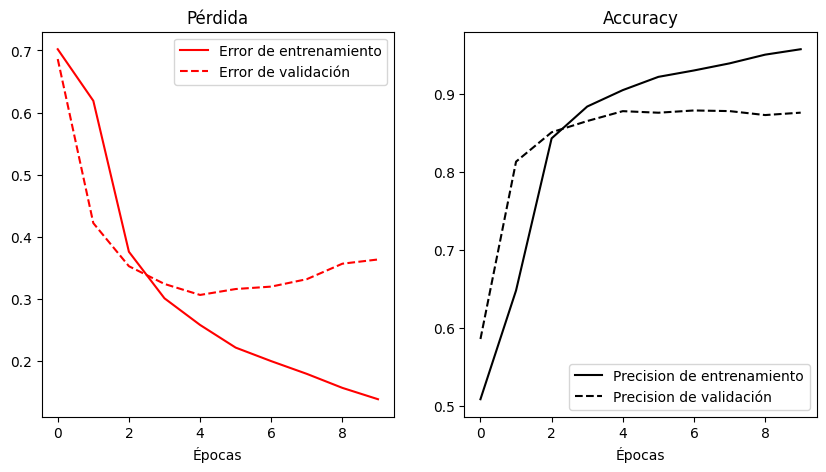

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.subplot(121)
plt.plot(history.history["loss"], "r", label="Error de entrenamiento")
plt.plot(history.history["val_loss"], "r--", label="Error de validación")
plt.xlabel("Épocas")
plt.title("Pérdida")
plt.legend()
plt.subplot(122)
plt.plot(history.history["accuracy"], "k", label="Precision de entrenamiento")
plt.plot(history.history["val_accuracy"], "k--", label="Precision de validación")
plt.xlabel("Épocas")
plt.title("Accuracy")
plt.legend()

# **3. Vision transformer vs text transformer**

Un transformer convencional, como los que se utilizan en procesamiento de lenguaje natural, trabaja con secuencias de texto divididas en tokens. Cada token representa una palabra o parte de una palabra, y el modelo aprende las relaciones entre ellos utilizando mecanismos de auto-atención, que permite capturar dependencias entre elementos cercanos y lejanos del texto. Esta arquitectura ha demostrado ser muy eficaz en tareas como traducción, clasificación de texto y respuesta a preguntas.

<center><img src="https://www.pinecone.io/_next/image/?url=https%3A%2F%2Fcdn.sanity.io%2Fimages%2Fvr8gru94%2Fproduction%2F7a096efc8f3cc40849ee17a546dc0e685da2dc73-4237x1515.png&w=3840&q=75" alt ="Gráfico ilustrativo de la pipeline de ejecución" width="80%" /></center>

Un [Vision Transformer](https://arxiv.org/pdf/2010.11929/1000) (ViT) toma esta misma arquitectura y la adapta para trabajar con imágenes en lugar de texto. En lugar de procesar palabras, el ViT divide una imagen en pequeños parches (por ejemplo, bloques de 16x16 píxeles). Estos se agrupan como si fueran una secuencia, al igual que una frase compuesta por tokens, y se procesan mediante las mismas capas de atención y redes neuronales del _transformer_ convencional.

Aunque trabajan con tipos de datos muy distintos, tanto los _transformers_ tradicionales como los Vision _Transformers_ funcionan sobre el principio de analizar relaciones entre elementos dentro de una secuencia. En el caso del texto, los elementos son palabras; en el caso de las imágenes, son regiones visuales. Ambos modelos pueden aprender patrones complejos sin necesidad de estructuras especializadas como convoluciones o recurrencias, lo que los hace muy flexibles y potentes en sus respectivos dominios.

# **4. _Compact Convolutional Transformers_**

Un [_Compact Convolutional Transformer_](https://arxiv.org/abs/2104.05704) (CCT) es un modelo de visión por computadora que combina la potencia de los transformers con la eficiencia de las redes convolucionales. A diferencia de los ViT originales, que dividen una imagen en parches y los tratan como una secuencia sin considerar la relación local entre píxeles, los CCT integran una capa convolucional inicial que extrae características locales antes de alimentar al transformer. Esto permite capturar mejor la estructura espacial de las imágenes, aprovechando tanto la capacidad de aprendizaje global de los transformers como la eficiencia local de las convoluciones.

<center><img src="https://production-media.paperswithcode.com/methods/cct_sBBD6Sv.png" alt ="Gráfico ilustrativo de la pipeline de ejecución" width="80%" /></center>

Usar un CCT en lugar de un ViT original es ventajoso especialmente en escenarios donde se tiene menos cantidad de datos o menor capacidad computacional. Los ViT requieren grandes volúmenes de datos para aprender correctamente las relaciones espaciales desde cero. En cambio, los CCT incorporan estos procesos convoluciones, lo que los hace más robustos y eficientes en tareas con conjuntos de datos más pequeños o limitados, como suele ocurrir en aplicaciones médicas o científicas. Además, suelen tener menos parámetros y requieren menos potencia de cómputo, haciéndolos ideales para implementaciones más ligeras sin sacrificar precisión.

## **4.1 Conjunto de datos:** CIFAR-10

Para este ejemplo usaremos el conjunto de datos [CIFAR-10](https://keras.io/api/datasets/cifar10/) contenido en _Keras_. El conjunto de datos CIFAR-10 consta de 60000 imágenes en color de 32x32 en 10 clases, con 6000 imágenes por clase. Hay 50000 imágenes de entrenamiento y 10000 imágenes de prueba.


In [10]:
keras.backend.clear_session()

Inicialmente, limpiaremos la sesión de Keras, liberando espacio en el sistema para el próximo experimento. Ahora carguemos el conjunto de datos.

In [1]:
num_classes = 10
input_shape = (32, 32, 3)

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print(f"Conjunto de entrenamiento:")
print(f"    Tamaño del conjunto entradas: {x_train.shape} - Tamaño de la salida: {y_train.shape}")
print(f"Conjunto de prueba:")
print(f"    Tamaño del conjunto entradas: {x_test.shape} - Tamaño de la salida: {y_test.shape}")

NameError: name 'keras' is not defined

Veamos algunos ejemplos:

In [ ]:
for i in range (16):
  plt.subplot(4,4,i+1)
  plt.imshow(x_train[i])
  plt.axis('off')

plt.show()

## **4.2 Vision tokenizer**

La principal diferencia entre un ViT y un CCT yace en el tokenizador. Como lo mencionamos anteriormente, el ViT fragmenta la imagen en pequeños parches que componen el conjunto de tokens. Por otra parte, el CCT emplea una red neuronal convolucional para extraer una serie de mapas de activación que funcionan como tokenes.

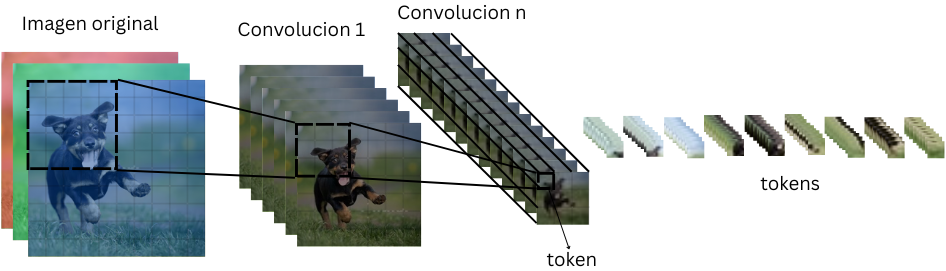

Implementemos el Tokenizador convolucional:

In [ ]:
class CCTTokenizer(keras.layers.Layer):
    def __init__(
        self,
        image_shape = (32,32,3),
        kernel_size=3,
        stride=1,
        padding=1,
        pooling_kernel_size=3,
        pooling_stride=2,
        num_output_channels=[64, 128],
        **kwargs,
    ):
        super().__init__(**kwargs)

        # This is our tokenizer.
        self.conv_model = keras.Sequential()
        self.conv_model.add(keras.layers.Input(shape=image_shape))
        for i in range(len(num_output_channels)):
            self.conv_model.add(
                keras.layers.Conv2D(
                    num_output_channels[i],
                    kernel_size,
                    stride,
                    padding="valid",
                    use_bias=False,
                    activation="relu",
                    kernel_initializer="he_normal"
                    )
                )
            self.conv_model.add(keras.layers.ZeroPadding2D(padding))
            self.conv_model.add(keras.layers.MaxPooling2D(pooling_kernel_size, pooling_stride, "same"))

    def call(self, images):
        outputs = self.conv_model(images)
        # After passing the images through our mini-network the spatial dimensions
        # are flattened to form sequences.
        reshaped = keras.ops.reshape(outputs, (-1,keras.ops.shape(outputs)[1] * keras.ops.shape(outputs)[2], keras.ops.shape(outputs)[-1]))
        return reshaped

In [ ]:
tokenizador = CCTTokenizer()
tokenizador.conv_model.summary()

Noté que gracias al proceso de pooling entre las capas convolucionales, la imagen original es reducida a una matriz de un tamaño menor (8x8), pero con mayor profundidad (128), donde cada píxel caracteriza espacialmente una región de la imagen. Ahora, estos píxeles serán interpretados como tokens, estando representados en un espacio de 128 canales o filtros. Recuerde que los Transformers originalmente no preservan información posicional, por lo que se usa la función reshape para transformar la matriz resultante en una lista de 64 tokens con una dimensionalidad de 128.


In [ ]:
tokens = tokenizador(x_train[:10])
print(tokens.shape)


## **4.3 Codificación posicional**

Al igual que en el caso anterior es necesario introducir la infromación posocional al modelo, usaremos nuevamente la capa de `Embeeding`. Sin emabrgo, este encoder posicional 2D funciona aprendiendo representaciones separadas para las coordenadas de fila y columna de cada parche en la cuadrícula de la imagen dividida. Se utilizan dos capas Embedding: una para las filas y otra para las columnas. Para cada parche, se obtienen sus índices de fila y columna correspondientes dentro de la cuadrícula. Estos índices se utilizan para buscar los embeddings aprendidos en sus respectivas capas. Finalmente, los embeddings de fila y columna para cada parche se suman para crear un vector único que codifica su posición 2D dentro de la imagen. Este vector posicional se adiciona luego al embedding del parche de la imagen, permitiendo al modelo tener en cuenta la ubicación espacial de cada parte de la imagen.

In [ ]:
class CCTPosEmbedding(keras.layers.Layer):
    def __init__(self, tokens_x, tokens_y, emb_size, **kwargs):
        super().__init__(**kwargs)
        self.tokens_x = tokens_x
        self.tokens_y = tokens_y
        self.emb_size = emb_size
        self.x_emb = keras.layers.Embedding(input_dim=tokens_x, output_dim=emb_size)
        self.y_emb = keras.layers.Embedding(input_dim=tokens_y, output_dim=emb_size)


    def call(self, images):
        batch_size = keras.ops.shape(images)[0]
        x_pos = np.array([[i]*self.tokens_y for i in range(self.tokens_x)]).flatten()
        y_pos = np.array([i for i in range(self.tokens_y)]*self.tokens_x).flatten()
        positions_x = keras.ops.tile(keras.ops.expand_dims(x_pos, axis=0), [batch_size, 1])
        positions_y = keras.ops.tile(keras.ops.expand_dims(y_pos, axis=0), [batch_size, 1])
        emb = self.x_emb(positions_x) + self.y_emb(positions_y)
        return emb

In [ ]:
PosEmbedder = CCTPosEmbedding(8,8, 128)
PosEncoding = PosEmbedder(x_train[0:10])
print(PosEncoding.shape)

## **4.4 Agregación o _Pooling_**

La capa de SequencePoolinges una pieza crucial después de que la imagen se divide en parches y se procesa a través de las capas del Transformer. Al tratar la secuencia de embeddings de los parches como una secuencia temporal, esta capa de pooling con atención permite al modelo aprender a ponderar la importancia de diferentes parches para la tarea específica en cuestión (como la clasificación de imágenes). En lugar de simplemente tomar un promedio o el embedding del primer token (como el [CLS]), la atención permite que el modelo determine dinámicamente qué regiones de la imagen (representadas por los parches) son más relevantes para la decisión final, creando una representación agregada más informativa y adaptativa de la imagen completa.

In [ ]:
class SequencePooling(keras.layers.Layer):
    def __init__(self):
        super().__init__()
        self.attention = keras.layers.Dense(1)

    def call(self, x):
        attention_weights = keras.ops.softmax(self.attention(x), axis=1)
        attention_weights = keras.ops.transpose(attention_weights, axes=(0, 2, 1))
        weighted_representation = keras.ops.matmul(attention_weights, x)
        return keras.ops.squeeze(weighted_representation, -2)


## **4.5 Modelo**

Una vez diseñado el tokenizador podemos mantener la estructura empleada en el ejemplo anterior para construir nuestro modelo.

In [ ]:
keras.backend.clear_session()

embed_dim = 128  # Tamaño de la representación
num_heads = 2  # numero de capas de atención
ff_dim = 128  # tamaño de la representacion interna del codificador

inputs = keras.layers.Input(shape=(32,32,3))

embedding_layer = CCTTokenizer()
pos_embedding_layer = CCTPosEmbedding(8,8, 128)
transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim)

context_embedding = embedding_layer(inputs)
pos_embedding = pos_embedding_layer(context_embedding)
x = keras.layers.Add()([context_embedding, pos_embedding]) # Suma de la codificación posicional y el vector de representacion de cada token
x = transformer_block(x)
x = SequencePooling()(x)
x = keras.layers.Dropout(0.1)(x)
x = keras.layers.Dense(20, activation="relu")(x)
x = keras.layers.Dropout(0.1)(x)
outputs = keras.layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

## **4.6 Entrenamiento y evaluación**

Ahora entrenaermos y evaluaremos el modelo en términos de _accuracy, recall, precision_ y f1:

In [ ]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss="categorical_crossentropy", metrics=[keras.metrics.TopKCategoricalAccuracy(5, name="top-5-accuracy"), keras.metrics.CategoricalAccuracy(name="accuracy")])
history = model.fit(
    x_train, y_train, batch_size=128, epochs=30, validation_data=(x_test, y_test)
)

In [ ]:
import numpy as np
print(classification_report(np.argmax(y_test[:1000], axis=1), np.argmax(model(x_test[:1000]), axis=1)))

Por último, compararemos las pérdidas y el accuracy del modelo a lo largo de las iteraciones:

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.plot(history.history["loss"], "r", label="Error de entrenamiento")
plt.plot(history.history["val_loss"], "r--", label="Error de validación")
plt.xlabel("Épocas")
plt.title("Pérdida")
plt.legend()
plt.subplot(132)
plt.plot(history.history["accuracy"], "k", label="Precision de entrenamiento")
plt.plot(history.history["val_accuracy"], "k--", label="Precision de validación")
plt.xlabel("Épocas")
plt.title("Accuracy")
plt.legend()
plt.subplot(133)
plt.plot(history.history["top-5-accuracy"], "k", label="Top 5 precision de entrenamiento")
plt.plot(history.history["val_top-5-accuracy"], "k--", label="Top 5 precision de validación")
plt.xlabel("Épocas")
plt.title("Top 5 Accuracy")
plt.legend()